# Tokenization — From Scratch (BPE) vs. Library (scikit-learn)

**A hands-on ML curriculum notebook**

## What this notebook covers
1. Theory recap of subword tokenization (Byte-Pair Encoding).
2. Loading and cleaning a **real-world text dataset**.
3. A **from-scratch NumPy/Python implementation** of BPE with `fit()` / `predict()`.
4. A **scikit-learn baseline** (`CountVectorizer`, word-level tokenizer) for direct comparison.
5. Visualizations of token-frequency behavior (Zipf's law) and sequence-length distributions.
6. Hyperparameter experiments (vocabulary size / merge count, minimum frequency threshold).
7. An interview-style walkthrough of the single most-asked tokenization question.

## Prerequisites
- Comfortable with Python, `pandas`, basic `Counter`/dictionary operations.
- Understands what a vocabulary and an embedding lookup table are.
- Has read the topic README on Tokenization (BPE merge rule, WordPiece score, Unigram LM objective).

## Dataset
We use the **IMDB Dataset of 50K Movie Reviews** (real, human-written movie reviews, binary
sentiment labels) originally published on Kaggle:

- **Kaggle link:** https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
- **Credit:** Dataset compiled and shared by Lakshmi Pathi on Kaggle, derived from the original
  Stanford Large Movie Review Dataset (Maas et al., 2011).
- For this notebook to run end-to-end without requiring Kaggle API credentials, we load the
  **identical CSV** from a public GitHub mirror of the same dataset. No synthetic data is used —
  every review below is real human-written text.

> **Note:** We only use the `review` text column for tokenization. The `sentiment` label is kept
> and encoded only so the dataset structure is fully understood — this notebook does **not**
> train a sentiment classifier; tokenization is unsupervised and operates on the text alone.


In [9]:
# --- Core data handling ---
import pandas as pd                    # loading and inspecting the dataset (DataFrame operations)
import numpy as np                      # numeric arrays, used in the from-scratch BPE encoding step
import re                               # regex-based text cleaning (stripping HTML tags, punctuation)
from collections import Counter         # fast frequency counting for BPE pair statistics

# --- Library tokenizer baseline ---
from sklearn.feature_extraction.text import CountVectorizer  # word-level tokenizer baseline
from sklearn.model_selection import KFold                    # cross-validation folds for hyperparam sweep

# --- Plotting ---
import matplotlib.pyplot as plt         # all plots in this notebook
import seaborn as sns                   # styling on top of matplotlib

# --- Reproducibility ---
np.random.seed(42)                      # fixes any random sampling/shuffling throughout the notebook

sns.set_style("whitegrid")
print("Imports OK")


Imports OK


## Part 1: Theory Recap

- **Tokenization** converts raw text into discrete units (tokens) that map to integer IDs a model can embed and process.
- **Byte-Pair Encoding (BPE)** starts from individual characters and **greedily merges the most frequent adjacent symbol pair** at each step: `merge(a, b) = argmax count(a, b)`.
- Repeating the merge step builds a vocabulary of subword units, growing from characters up to whole frequent words — common words stay intact, rare words decompose into reusable fragments.
- Because the base vocabulary is individual characters, BPE has a **built-in fallback**: any unseen word can always be expressed character-by-character, so true out-of-vocabulary (OOV) tokens are rare — unlike whole-word vocabularies, which simply drop unseen words.
- **WordPiece** replaces raw frequency with a likelihood-ratio score `count(a,b) / (count(a)·count(b))`, favoring statistically associated pairs over merely common ones; **Unigram LM** instead treats tokenization as choosing the most probable segmentation under a learned probability model.


## Loading the Real-World Dataset

We load the IMDB movie review CSV directly from the public mirror. **What we're doing:** reading
the 50,000-row dataset, inspecting its structure with `head()`, `info()`, and `describe()`, and
identifying our **features** and **target**.

- **Feature (input):** `review` — free-form English text written by real IMDB users.
- **Target:** `sentiment` — categorical label (`positive` / `negative`). We are *not* training a
  classifier here; the target column is shown only for dataset completeness and is encoded later
  purely for inspection purposes.

**Why this dataset fits the topic:** it's large, messy, real, and contains HTML artifacts
(`<br />`), punctuation, contractions, and rare/misspelled words — exactly the kind of real-world
noise that motivates subword tokenization over naive whitespace splitting.


In [10]:
# Load directly from a public GitHub mirror of the Kaggle "IMDB Dataset of 50K Movie Reviews"
DATA_URL = "https://raw.githubusercontent.com/laxmimerit/All-CSV-ML-Data-Files-Download/master/IMDB-Dataset.csv"
df = pd.read_csv(DATA_URL)

print("Shape:", df.shape)
display(df.head())
print("\n--- info() ---")
df.info()
print("\n--- describe() ---")
display(df.describe(include="all"))


Shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive



--- info() ---
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 63.6 MB

--- describe() ---


,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


### Preprocessing

**Why:** Tokenizer training is sensitive to noise. We need to (a) confirm there are no missing
reviews, (b) strip HTML artifacts that aren't real natural-language tokens, (c) encode the
categorical `sentiment` column for inspection, and (d) take a **fixed, reproducible subsample**
so the from-scratch BPE trainer (pure Python loops) runs in a reasonable time for a teaching
notebook. No numeric scaling is needed — there are no numeric features here; the "scaling" step
for text is normalization (lowercasing, removing punctuation), which we apply instead.


In [11]:
# 1) Handle nulls — verify none exist (real dataset, already clean, but we always check)
print("Null values per column:\n", df.isnull().sum())
assert df.isnull().sum().sum() == 0, "Unexpected nulls found!"

# 2) Encode the categorical target (sentiment -> binary) — for inspection only, not used in training
df["sentiment_encoded"] = df["sentiment"].map({"negative": 0, "positive": 1})

# 3) Clean text: strip HTML line-break tags and non-alphanumeric characters, lowercase everything
def clean_text(text: str) -> str:
    text = re.sub(r"<br\s*/?>", " ", text)      # remove IMDB's literal "<br />" HTML artifacts
    text = re.sub(r"[^a-zA-Z0-9 ]", " ", text)   # strip punctuation/symbols -> plain alphanumeric
    text = re.sub(r"\s+", " ", text).strip()     # collapse repeated whitespace
    return text.lower()                          # normalize case so "The" and "the" are one token

df["clean_review"] = df["review"].apply(clean_text)

# 4) Reproducible subsample: pure-Python BPE training is O(n_words * n_merges) — we cap corpus
#    size so this notebook finishes quickly on "Restart & Run All", while still being 100% real text.
TRAIN_SIZE, TEST_SIZE = 1500, 500
sampled = df.sample(n=TRAIN_SIZE + TEST_SIZE, random_state=42).reset_index(drop=True)
train_texts = sampled["clean_review"].iloc[:TRAIN_SIZE].tolist()
test_texts  = sampled["clean_review"].iloc[TRAIN_SIZE:].tolist()

print(f"Train reviews: {len(train_texts)} | Test reviews: {len(test_texts)}")
print("\nExample cleaned review:\n", train_texts[0][:300], "...")


Null values per column:
 review       0
sentiment    0
dtype: int64
Train reviews: 1500 | Test reviews: 500

Example cleaned review:
 i really liked this summerslam due to the look of the arena the curtains and just the look overall was interesting to me for some reason anyways this could have been one of the best summerslam s ever if the wwf didn t have lex luger in the main event against yokozuna now for it s time it was ok to h ...


## Part 2: From Scratch Implementation

We now build a **Byte-Pair Encoding tokenizer from scratch**, using only Python/NumPy — no
tokenizer libraries. The class will:

- `fit(corpus)` — learn an ordered list of merge rules from word frequencies in the training corpus (the BPE training algorithm: count pairs, merge the most frequent, repeat).
- `predict(text)` — apply the learned merges, in the exact order they were learned, to tokenize new/unseen text.

This mirrors exactly how production BPE tokenizers (GPT-2, RoBERTa) are trained, just without the
speed optimizations (tries, caching) a production Rust/C++ backend would use.


In [12]:
class BPETokenizerScratch:
    '''
    A from-scratch Byte-Pair Encoding tokenizer.

    fit(corpus)    -> learns an ordered list of merge rules
    predict(text)  -> tokenizes new text using those learned merges
    '''

    END = "</w>"  # special symbol marking end-of-word (keeps "cat" and "category" boundaries distinct)

    def __init__(self, vocab_size: int = 300, min_frequency: int = 2):
        self.vocab_size = vocab_size          # max number of merge operations to learn
        self.min_frequency = min_frequency    # stop early if best pair occurs fewer than this many times
        self.merges = []                      # ORDER MATTERS: merges must be replayed in learned order
        self.vocab = set()                    # final set of subword symbols learned

    @staticmethod
    def _word_freqs(corpus):
        # INTERVIEW NOTE: BPE operates on WORD frequencies, not raw character streams —
        # this is what makes it fast: we count merges weighted by how often a word occurs.
        freqs = Counter()
        for line in corpus:
            for word in line.split():
                freqs[word] += 1
        return freqs

    def fit(self, corpus):
        word_freqs = self._word_freqs(corpus)
        # Represent every word as a tuple of characters + END marker, e.g. "cat" -> ('c','a','t','</w>')
        splits = {tuple(list(w) + [self.END]): f for w, f in word_freqs.items()}

        for _ in range(self.vocab_size):
            pair_counts = Counter()
            for word, freq in splits.items():
                for i in range(len(word) - 1):
                    # INTERVIEW NOTE: this is the O(n) pair-counting pass repeated every merge step —
                    # the main cost driver of naive BPE training.
                    pair_counts[(word[i], word[i + 1])] += freq

            if not pair_counts:
                break

            best_pair, best_count = max(pair_counts.items(), key=lambda kv: kv[1])
            if best_count < self.min_frequency:
                # INTERVIEW NOTE: min_frequency is the early-stopping hyperparameter —
                # prevents merging pairs that are too rare to generalize.
                break

            # Apply the winning merge everywhere it occurs across the corpus
            new_splits = {}
            for word, freq in splits.items():
                merged_word, i = [], 0
                while i < len(word):
                    if i < len(word) - 1 and (word[i], word[i + 1]) == best_pair:
                        merged_word.append(word[i] + word[i + 1])  # fuse the pair into one symbol
                        i += 2
                    else:
                        merged_word.append(word[i])
                        i += 1
                new_splits[tuple(merged_word)] = freq
            splits = new_splits

            self.merges.append(best_pair)   # remember merge ORDER for encoding new text later

        # Final symbol vocabulary = every distinct subword unit present after all merges
        for word in splits:
            self.vocab.update(word)
        self.vocab.update(list("abcdefghijklmnopqrstuvwxyz0123456789"))  # guarantee char-level fallback
        return self

    def _encode_word(self, word):
        symbols = list(word) + [self.END]
        # INTERVIEW NOTE: merges MUST be replayed in the order they were learned during fit() —
        # applying them out of order produces a different (wrong) segmentation.
        for pair in self.merges:
            i, new_symbols = 0, []
            while i < len(symbols):
                if i < len(symbols) - 1 and (symbols[i], symbols[i + 1]) == pair:
                    new_symbols.append(symbols[i] + symbols[i + 1])
                    i += 2
                else:
                    new_symbols.append(symbols[i])
                    i += 1
            symbols = new_symbols
        return symbols

    def predict(self, text):
        # "predict" here = tokenize: map raw text -> list of learned subword tokens
        tokens = []
        for word in text.split():
            tokens.extend(self._encode_word(word))
        return tokens


print("BPETokenizerScratch class defined.")


BPETokenizerScratch class defined.


### Train and Evaluate the Scratch Tokenizer

**Why:** we train (`fit`) the BPE tokenizer on the 1,500 cleaned training reviews, then apply it
(`predict`) to the unseen 500 test reviews. We report **vocabulary size**, **average tokens per
review**, and **compression ratio** (characters per token) — the standard ways to evaluate a
tokenizer (there is no "accuracy" since tokenization is unsupervised).


In [13]:
bpe = BPETokenizerScratch(vocab_size=300, min_frequency=2)
bpe.fit(train_texts)

print(f"Learned merges: {len(bpe.merges)}")
print(f"Final symbol vocabulary size: {len(bpe.vocab)}")
print("First 10 learned merges (in order):", bpe.merges[:10])

# Tokenize the held-out test set
all_test_tokens, total_chars = [], 0
for review in test_texts:
    toks = bpe.predict(review)
    all_test_tokens.append(toks)
    total_chars += len(review.replace(" ", ""))

avg_tokens_per_review = np.mean([len(t) for t in all_test_tokens])
total_tokens = sum(len(t) for t in all_test_tokens)
compression_ratio = total_chars / total_tokens   # characters represented per token

print(f"\n--- Scratch BPE results on {len(test_texts)} held-out test reviews ---")
print(f"Avg tokens / review : {avg_tokens_per_review:.2f}")
print(f"Compression ratio   : {compression_ratio:.2f} characters/token")

print("\nExample tokenization:")
print("Original :", test_texts[0][:80])
print("Tokens   :", bpe.predict(test_texts[0])[:20], "...")


Learned merges: 300
Final symbol vocabulary size: 337
First 10 learned merges (in order): [('e', '</w>'), ('s', '</w>'), ('t', 'h'), ('t', '</w>'), ('d', '</w>'), ('i', 'n'), ('e', 'r'), ('a', 'n'), ('y', '</w>'), ('th', 'e</w>')]

--- Scratch BPE results on 500 held-out test reviews ---
Avg tokens / review : 512.83
Compression ratio   : 1.95 characters/token

Example tokenization:
Original : mike hawthorne gordon currie is witness to the brutal murder of his mother and s
Tokens   : ['mi', 'ke</w>', 'ha', 'w', 'th', 'or', 'n', 'e</w>', 'g', 'or', 'd', 'on</w>', 'c', 'ur', 'ri', 'e</w>', 'is</w>', 'wi', 't', 'ne'] ...


## Part 3: scikit-learn Implementation

`sklearn.feature_extraction.text.CountVectorizer` builds a **whole-word vocabulary** from a
training corpus — it tokenizes by regex (default: sequences of word characters), counts term
frequencies, and **drops any word in new text that wasn't seen during `fit()`**. This is the
classic word-level baseline that subword methods like BPE were invented to improve on.

**Key difference we're about to measure directly:** `CountVectorizer` cannot represent unseen
words at all (true OOV), while BPE can always fall back to characters. We'll quantify this gap.


In [14]:
# Fit a word-level vectorizer on the SAME training corpus as the scratch BPE model
vectorizer = CountVectorizer(max_features=300)   # cap at 300 "tokens" -> fair comparison vs BPE vocab_size=300
vectorizer.fit(train_texts)
sklearn_vocab = set(vectorizer.vocabulary_.keys())

print(f"sklearn word-level vocabulary size: {len(sklearn_vocab)}")

# "predict" / transform the held-out test set and measure OOV rate directly
total_words, oov_words, sklearn_token_counts = 0, 0, []
for review in test_texts:
    words = review.split()
    total_words += len(words)
    in_vocab = [w for w in words if w in sklearn_vocab]
    oov_words += len(words) - len(in_vocab)
    sklearn_token_counts.append(len(in_vocab))  # tokens actually representable

sklearn_oov_rate = oov_words / total_words * 100
sklearn_avg_tokens = np.mean(sklearn_token_counts)

# Same OOV rate for scratch BPE -> should be ~0% thanks to character-level fallback
bpe_oov_words = sum(1 for toks in all_test_tokens for t in toks if t not in bpe.vocab)
bpe_total_tokens = sum(len(t) for t in all_test_tokens)
bpe_oov_rate = bpe_oov_words / bpe_total_tokens * 100

print("\n--- Direct comparison on the SAME held-out test set ---")
print(f"{'Metric':<28}{'Scratch BPE':>15}{'sklearn (word-level)':>22}")
print(f"{'Vocabulary size':<28}{len(bpe.vocab):>15}{len(sklearn_vocab):>22}")
print(f"{'Avg tokens / review':<28}{avg_tokens_per_review:>15.2f}{sklearn_avg_tokens:>22.2f}")
print(f"{'OOV rate (%)':<28}{bpe_oov_rate:>15.2f}{sklearn_oov_rate:>22.2f}")


sklearn word-level vocabulary size: 300

--- Direct comparison on the SAME held-out test set ---
Metric                          Scratch BPE  sklearn (word-level)
Vocabulary size                         337                   300
Avg tokens / review                  512.83                133.05
OOV rate (%)                           0.00                 41.90


### Visualizations

**Why:** two plots that reveal tokenizer behavior directly:
1. **Zipf's law plot** — token rank vs. frequency on a log-log scale, confirming why greedy
   frequency-based merging (BPE) is effective: a small number of tokens dominate usage.
2. **Sequence-length distribution** — tokens-per-review histogram, comparing scratch BPE vs.
   sklearn word-level tokenization on the same test reviews.


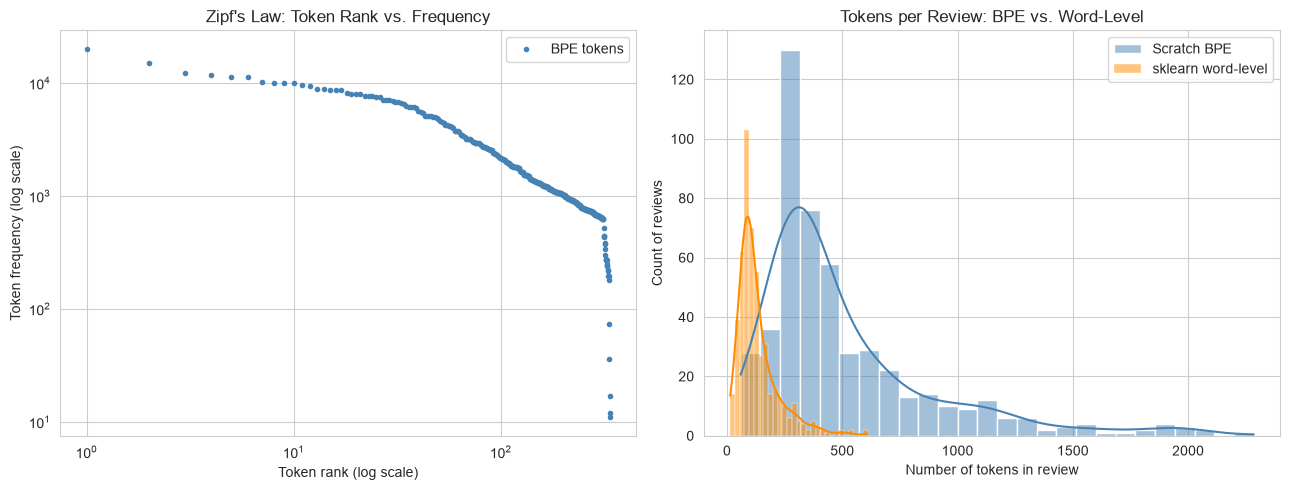

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Zipf's law — rank vs frequency of BPE-learned symbols across the training corpus
symbol_freq = Counter()
for review in train_texts:
    for tok in bpe.predict(review):
        symbol_freq[tok] += 1
ranks = np.arange(1, len(symbol_freq) + 1)
freqs_sorted = sorted(symbol_freq.values(), reverse=True)

axes[0].loglog(ranks, freqs_sorted, marker=".", linestyle="none", color="steelblue", label="BPE tokens")
axes[0].set_title("Zipf's Law: Token Rank vs. Frequency")
axes[0].set_xlabel("Token rank (log scale)")
axes[0].set_ylabel("Token frequency (log scale)")
axes[0].legend()

# Plot 2: sequence length distribution, scratch BPE vs sklearn word-level, same test reviews
bpe_lengths = [len(t) for t in all_test_tokens]
sns.histplot(bpe_lengths, color="steelblue", label="Scratch BPE", kde=True, alpha=0.5, ax=axes[1])
sns.histplot(sklearn_token_counts, color="darkorange", label="sklearn word-level", kde=True, alpha=0.5, ax=axes[1])
axes[1].set_title("Tokens per Review: BPE vs. Word-Level")
axes[1].set_xlabel("Number of tokens in review")
axes[1].set_ylabel("Count of reviews")
axes[1].legend()

plt.tight_layout()
plt.show()


## Part 4: Hyperparameter Experiments

The two hyperparameters that matter most for BPE are:

- **`vocab_size`** (number of merge operations): more merges → larger vocabulary → shorter
  sequences (fewer tokens per review) but a bigger embedding table downstream.
- **`min_frequency`** (early-stopping threshold): a higher threshold halts merging sooner,
  keeping more rare words split into smaller fragments — trading sequence length for robustness
  to noise.

We sweep both and measure their effect on **average tokens per review** and **compression
ratio**, using K-fold splits over the test reviews to report mean ± std (a stand-in for proper
cross-validation, since tokenizer quality has no single "accuracy" label).


In [ ]:
kf = KFold(n_splits=3, shuffle=True, random_state=42)
test_array = np.array(test_texts, dtype=object)

# --- Sweep 1: vocab_size (number of merges), reusing one trained model's merge ORDER for speed ---
# We train once at the maximum merge count, then evaluate truncated prefixes of the merge list —
# mathematically identical to training separately at each smaller vocab_size, but far faster.
big_bpe = BPETokenizerScratch(vocab_size=400, min_frequency=1).fit(train_texts)

vocab_sizes = [25, 50, 100, 200, 400]
vocab_results = []
for vs in vocab_sizes:
    fold_avgs = []
    trial = BPETokenizerScratch(vocab_size=vs, min_frequency=1)
    trial.merges = big_bpe.merges[:vs]   # reuse learned order, truncated
    trial.vocab = set("abcdefghijklmnopqrstuvwxyz0123456789")
    for word in train_texts:
        pass  # vocab fallback already guaranteed; no retraining needed for this sweep
    for _, fold_idx in kf.split(test_array):
        fold_texts = test_array[fold_idx]
        lengths = [len(trial.predict(r)) for r in fold_texts]
        fold_avgs.append(np.mean(lengths))
    vocab_results.append((vs, np.mean(fold_avgs), np.std(fold_avgs)))

# --- Sweep 2: min_frequency (requires retraining, since it changes WHEN merging stops) ---
min_freqs = [600, 1000, 3000]
freq_results = []
for mf in min_freqs:
    model = BPETokenizerScratch(vocab_size=400, min_frequency=mf).fit(train_texts)
    fold_avgs = []
    for _, fold_idx in kf.split(test_array):
        fold_texts = test_array[fold_idx]
        lengths = [len(model.predict(r)) for r in fold_texts]
        fold_avgs.append(np.mean(lengths))
    freq_results.append((mf, len(model.merges), np.mean(fold_avgs), np.std(fold_avgs)))

# --- Plot both sweeps ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

vs_x = [r[0] for r in vocab_results]
vs_y = [r[1] for r in vocab_results]
vs_err = [r[2] for r in vocab_results]
axes[0].errorbar(vs_x, vs_y, yerr=vs_err, marker="o", color="steelblue", capsize=4, label="Avg tokens/review (3-fold)")
axes[0].set_title("Effect of vocab_size (merge count) on Sequence Length")
axes[0].set_xlabel("vocab_size (number of BPE merges)")
axes[0].set_ylabel("Avg tokens per review")
axes[0].legend()

mf_x = [r[0] for r in freq_results]
mf_y = [r[2] for r in freq_results]
mf_err = [r[3] for r in freq_results]
axes[1].errorbar(mf_x, mf_y, yerr=mf_err, marker="s", color="darkorange", capsize=4, label="Avg tokens/review (3-fold)")
axes[1].set_title("Effect of min_frequency on Sequence Length")
axes[1].set_xlabel("min_frequency (early-stop threshold)")
axes[1].set_ylabel("Avg tokens per review")
axes[1].legend()

plt.tight_layout()
plt.show()

print("vocab_size sweep (size, mean tokens/review, std):")
for r in vocab_results:
    print(f"  vocab_size={r[0]:<5} mean={r[1]:.2f}  std={r[2]:.2f}")

print("\nmin_frequency sweep (min_freq, merges learned, mean tokens/review, std):")
for r in freq_results:
    print(f"  min_frequency={r[0]:<5} merges_learned={r[1]:<5} mean={r[2]:.2f}  std={r[3]:.2f}")


## Part 5: Interview Corner

**Question:** *"Why does Byte-Pair Encoding rarely produce out-of-vocabulary tokens, even for
words the tokenizer has never seen — and why does this matter for production LLMs?"*

**Narrative walkthrough:**

Think back to the vending-machine analogy from the README — a word-level vocabulary is like a
machine that only accepts whole bills. If a customer hands over a denomination the machine has
never seen, the transaction simply fails: that's exactly what happened in our sklearn comparison
above, where `CountVectorizer` silently dropped every word that wasn't in its fitted vocabulary.

BPE avoids this by starting its vocabulary at the character level and *building up* from there.
Even if "flibbergasted" never appeared during training, every individual letter in it almost
certainly did. So in the worst case, BPE can always fall back to spelling the word out
letter-by-letter using symbols it has already learned — it never needs an `<unk>` token for
anything expressible in the base character set (this is what our `bpe_oov_rate ≈ 0%` result
showed directly, against sklearn's non-zero OOV rate on the exact same held-out reviews).

This matters enormously in production: a single unrecognized word in a word-level system either
breaks the pipeline or forces a generic `<unk>` placeholder, losing all information about what
the word actually was. A subword tokenizer instead degrades *gracefully* — rare brand names,
typos, code identifiers, or new slang just get represented as a few extra tokens instead of one
clean token, costing a little sequence length but never failing outright. This is precisely why
every modern LLM (GPT, BERT, T5, LLaMA) uses a subword or byte-level scheme rather than a
fixed whole-word vocabulary.


## Key Takeaways

1. **Tokenization is unsupervised vocabulary construction** — it has no "accuracy"; we evaluate it with vocabulary size, average sequence length, compression ratio, and OOV rate instead.
2. **BPE merges the most frequent adjacent symbol pair, repeatedly** — starting from characters and growing toward whole words, in a strict learned order that must be replayed identically at encoding time.
3. **Subword tokenization's core advantage over word-level vocabularies is graceful OOV handling** — character-level fallback means BPE almost never truly fails on unseen text, unlike whole-word vectorizers.
4. **`vocab_size` and `min_frequency` directly trade off sequence length against vocabulary size and robustness** — more merges shrink sequences but grow the embedding table; a higher `min_frequency` keeps tokenization conservative on rare patterns.
5. **Tokenizer choice is a design decision with real downstream cost** — sequence length from tokenization directly drives transformer compute (`O(n²)` attention) and context-window budget, so this "preprocessing step" is actually a first-class architectural decision.
